In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import seaborn as sns
import geopandas as gpd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import pickle
import joblib


pd.options.mode.copy_on_write = True

# Preparando Dados

In [77]:
df = pd.read_csv("../dados/curitiba_foursquare_processed.csv")
df

,ID_USER,DATE,LAT,LONG,ID_VENUE,SUBCATEGORIA_VENUE,CATEGORIA_MAE,PAIS,CIDADE,BAIRRO,GENERO,OFFSET_HORARIO,CIDADE__PELO_METODO2,PAIS_PELO_METODO2,geometry,index_right,Bairro
0,59907035,2014-02-12T15:54:32Z,-25.469176,-49.282521,4ea6a728f9f4564b4c5f8bec,Sandwich-Place,Sandwiches,Brasil,Curitiba,notFound,male,-120,Curitiba,Brazil,POINT (-49.2825208604 -25.4691758047),4,GUAÍRA
1,21015914,2014-03-24T19:46:41Z,-25.474154,-49.290013,4f5678dee4b0b1792de1b0b4,Residential-Building-(Apartment-/-Condo),Residential,Brasil,Curitiba,notFound,female,-180,Curitiba,Brazil,POINT (-49.2900125549 -25.4741540315),20,PORTÃO
2,21015914,2014-03-24T19:46:41Z,-25.474154,-49.290013,4f5678dee4b0b1792de1b0b4,Residential-Building-(Apartment-/-Condo),Residential,Brasil,Curitiba,notFound,female,-180,Curitiba,Brazil,POINT (-49.2900125549 -25.4741540315),20,PORTÃO
3,43112636,2014-04-24T02:45:41Z,-25.462514,-49.277967,506392dce4b033080184462c,Soccer-Stadium,Soccer,Brasil,Curitiba,notFound,female,-180,Curitiba,Brazil,POINT (-49.2779671403 -25.4625139207),0,ÁGUA VERDE
4,37412621,2014-04-24T02:47:00Z,-25.438156,-49.279074,52ddec7d11d2052bdd2c8ace,Home-(private),Home,Brasil,Curitiba,notFound,male,-180,Curitiba,Brazil,POINT (-49.2790735502 -25.4381559118),49,CENTRO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18T21:38:07Z,-25.397451,-49.271144,51e46aca498ef59185492b1a,Fried-Chicken-Joint,Fried-Chicken,Brasil,Curitiba,notFound,male,-180,Curitiba,Brazil,POINT (-49.271144 -25.397451),39,SÃO LOURENÇO
53209,12974483,2014-06-18T21:41:13Z,-25.420876,-49.261371,4ce3e132b8df54815aa8b09b,Shrine,Shrine,Brasil,Curitiba,notFound,female,-180,Curitiba,Brazil,POINT (-49.2613710636 -25.4208764754),7,ALTO DA GLÓRIA
53210,17082636,2014-06-18T21:42:24Z,-25.440988,-49.277436,4b992d89f964a520436735e3,Mall,Mall,Brasil,Curitiba,notFound,male,-180,Curitiba,Brazil,POINT (-49.277436 -25.440988),49,CENTRO
53211,17082636,2014-06-18T21:42:35Z,-25.440845,-49.277071,4fbecc2ee4b0aeb0bc960792,Beer-Store,Beer-Store,Brasil,Curitiba,notFound,male,-180,Curitiba,Brazil,POINT (-49.2770711372 -25.4408446882),49,CENTRO


In [78]:
df.columns

Index(['ID_USER', 'DATE', 'LAT', 'LONG', 'ID_VENUE', 'SUBCATEGORIA_VENUE',
       'CATEGORIA_MAE', 'PAIS', 'CIDADE', 'BAIRRO', 'GENERO', 'OFFSET_HORARIO',
       'CIDADE__PELO_METODO2', 'PAIS_PELO_METODO2', 'geometry', 'index_right',
       'Bairro'],
      dtype='object')

In [79]:
df = df[['ID_USER', 'DATE', 'CATEGORIA_MAE', 'Bairro', 'LAT', 'LONG']]
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG
0,59907035,2014-02-12T15:54:32Z,Sandwiches,GUAÍRA,-25.469176,-49.282521
1,21015914,2014-03-24T19:46:41Z,Residential,PORTÃO,-25.474154,-49.290013
2,21015914,2014-03-24T19:46:41Z,Residential,PORTÃO,-25.474154,-49.290013
3,43112636,2014-04-24T02:45:41Z,Soccer,ÁGUA VERDE,-25.462514,-49.277967
4,37412621,2014-04-24T02:47:00Z,Home,CENTRO,-25.438156,-49.279074
...,...,...,...,...,...,...
53208,16620308,2014-06-18T21:38:07Z,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144
53209,12974483,2014-06-18T21:41:13Z,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371
53210,17082636,2014-06-18T21:42:24Z,Mall,CENTRO,-25.440988,-49.277436
53211,17082636,2014-06-18T21:42:35Z,Beer-Store,CENTRO,-25.440845,-49.277071


In [80]:
df["CATEGORIA_MAE"].value_counts()

CATEGORIA_MAE
Mall            3822
Home            3766
University      1792
Residential     1713
Shop            1657
                ... 
Carpet-Store       1
Embassy            1
B-&-B              1
Volcano            1
Preschool          1
Name: count, Length: 368, dtype: int64

In [81]:
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG
0,59907035,2014-02-12T15:54:32Z,Sandwiches,GUAÍRA,-25.469176,-49.282521
1,21015914,2014-03-24T19:46:41Z,Residential,PORTÃO,-25.474154,-49.290013
2,21015914,2014-03-24T19:46:41Z,Residential,PORTÃO,-25.474154,-49.290013
3,43112636,2014-04-24T02:45:41Z,Soccer,ÁGUA VERDE,-25.462514,-49.277967
4,37412621,2014-04-24T02:47:00Z,Home,CENTRO,-25.438156,-49.279074
...,...,...,...,...,...,...
53208,16620308,2014-06-18T21:38:07Z,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144
53209,12974483,2014-06-18T21:41:13Z,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371
53210,17082636,2014-06-18T21:42:24Z,Mall,CENTRO,-25.440988,-49.277436
53211,17082636,2014-06-18T21:42:35Z,Beer-Store,CENTRO,-25.440845,-49.277071


In [82]:
df['DATE'] = pd.to_datetime(df['DATE']).dt.tz_convert('America/Sao_Paulo')

# Extract hour of the day (0-23)
df['HOUR'] = df['DATE'].dt.hour

# Extract day of the week (0=Monday, 6=Sunday)
df['DAY_OF_WEEK'] = df['DATE'].dt.dayofweek

# Optional: Get day of week as text
df['DAY_NAME'] = df['DATE'].dt.day_name()

df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday
...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday


## Extrair Propósito

Prompt Usado

[ ... list with 50 categories ... ]

Help me map these categories to the following purposes:

WORK: Going to your usual place of work

HOME: Going Home

LEISURE: Leisure Activity (movie theater, restaurant, sports, walk, etc)

PURCHASE: Shopping or eerrands: bakery, store, hypermarket, etc.

OTHER: All the other stuff

Make it into a python dict "category": "PURPOSE" format that I can copy and paste in the order of the input

In [83]:
sorted(df["CATEGORIA_MAE"].unique())

['Academic-Building',
 'Acai',
 'Accessories',
 'Administrative-Building',
 'Advertising-Agency',
 'Airport',
 'American',
 'Animal-Shelter',
 'Antiques',
 'Apparel',
 'Arcade',
 'Argentinian',
 'Art-Gallery',
 'Art-Museum',
 'Arts',
 'Arts-&-Crafts',
 'Arts-&-Entertainment',
 'Asian',
 'Assisted-Living',
 'Athletics-&-Sports',
 'Auditorium',
 'Auto-Garage',
 'Automotive',
 'B-&-B',
 'BBQ',
 'Bagels',
 'Bakery',
 'Bank',
 'Bar',
 'Basketball',
 'Beach',
 'Beer-Garden',
 'Beer-Store',
 'Betting-Shop',
 'Big-Box-Store',
 'Bike',
 'Bike-shop',
 'Billiards',
 'Bistro',
 'Board-Shop',
 'Bookstore',
 'Botanical-Garden',
 'Boutique',
 'Bowling-Alley',
 'Brazilian',
 'Breakfast',
 'Brewery',
 'Bridal',
 'Bridge',
 'Buffet',
 'Building',
 'Burgers',
 'Bus',
 'Bus-Station',
 'Bus-Stop',
 'Butcher',
 'Cafeteria',
 'Café',
 'Campaign',
 'Campground',
 'Candy-Store',
 'Capitol-Building',
 'Car-Dealer',
 'Car-Wash',
 'Caribbean',
 'Carpet-Store',
 'Casino',
 'Castle',
 'Cemetery',
 'Cheese-Shop',
 '

In [84]:
category_to_purpose = {
    "Academic-Building": "WORK",
    "Acai": "LEISURE",
    "Accessories": "PURCHASE",
    "Administrative-Building": "WORK",
    "Advertising-Agency": "WORK",
    "Airport": "OTHER",
    "American": "LEISURE",
    "Animal-Shelter": "OTHER",
    "Antiques": "PURCHASE",
    "Apparel": "PURCHASE",
    "Arcade": "LEISURE",
    "Argentinian": "LEISURE",
    "Art-Gallery": "LEISURE",
    "Art-Museum": "LEISURE",
    "Arts": "OTHER",
    "Arts-&-Crafts": "PURCHASE",
    "Arts-&-Entertainment": "LEISURE",
    "Asian": "LEISURE",
    "Assisted-Living": "OTHER",
    "Athletics-&-Sports": "LEISURE",
    "Auditorium": "LEISURE",
    "Auto-Garage": "PURCHASE",
    "Automotive": "PURCHASE",
    "B-&-B": "OTHER",
    "BBQ": "LEISURE",
    "Bagels": "LEISURE",
    "Bakery": "PURCHASE",
    "Bank": "PURCHASE",
    "Bar": "LEISURE",
    "Basketball": "LEISURE",
    "Beach": "LEISURE",
    "Beer-Garden": "LEISURE",
    "Beer-Store": "PURCHASE",
    "Betting-Shop": "LEISURE",
    "Big-Box-Store": "PURCHASE",
    "Bike": "LEISURE",
    "Bike-shop": "PURCHASE",
    "Billiards": "LEISURE",
    "Bistro": "LEISURE",
    "Board-Shop": "PURCHASE",
    "Bookstore": "PURCHASE",
    "Botanical-Garden": "LEISURE",
    "Boutique": "PURCHASE",
    "Bowling-Alley": "LEISURE",
    "Brazilian": "LEISURE",
    "Breakfast": "LEISURE",
    "Brewery": "LEISURE",
    "Bridal": "PURCHASE",
    "Bridge": "OTHER",
    "Buffet": "LEISURE",
    "Building": "OTHER",
    "Burgers": "LEISURE",
    "Bus": "OTHER",
    "Bus-Station": "OTHER",
    "Bus-Stop": "OTHER",
    "Butcher": "PURCHASE",
    "Cafeteria": "LEISURE",
    "Café": "LEISURE",
    "Campaign": "OTHER",
    "Campground": "LEISURE",
    "Candy-Store": "PURCHASE",
    "Capitol-Building": "OTHER",
    "Car-Dealer": "PURCHASE",
    "Car-Wash": "PURCHASE",
    "Caribbean": "LEISURE",
    "Carpet-Store": "PURCHASE",
    "Casino": "LEISURE",
    "Castle": "LEISURE",
    "Cemetery": "OTHER",
    "Cheese-Shop": "PURCHASE",
    "Chinese": "LEISURE",
    "Chiropractors": "OTHER",
    "Chocolate-Shop": "PURCHASE",
    "Church": "OTHER",
    "Churrascaria": "LEISURE",
    "Cineplex": "LEISURE",
    "Circus-School": "LEISURE",
    "City": "OTHER",
    "City-Hall": "WORK",
    "Classroom": "WORK",
    "Club": "LEISURE",
    "Cocktail": "LEISURE",
    "Coffee-Shop": "LEISURE",
    "College-&-Education": "WORK",
    "Comedy-Club": "LEISURE",
    "Comfort-Food": "LEISURE",
    "Comic-Shop": "PURCHASE",
    "Communications": "WORK",
    "Community-Center": "OTHER",
    "Community-College": "WORK",
    "Concert-Hall": "LEISURE",
    "Conference-room": "WORK",
    "Convenience-Stores": "PURCHASE",
    "Convention": "WORK",
    "Convention-Center": "WORK",
    "Cosmetics": "PURCHASE",
    "Costume-Shop": "PURCHASE",
    "Country-Dance-Club": "LEISURE",
    "Courthouse": "WORK",
    "Coworking-Space": "WORK",
    "Creperie": "LEISURE",
    "Cultural-Center": "LEISURE",
    "Cupcakes": "LEISURE",
    "Dance-Studio": "LEISURE",
    "Daycare": "OTHER",
    "Deli-/-Bodega": "PURCHASE",
    "Dentist's-Office": "OTHER",
    "Department-Store": "PURCHASE",
    "Design": "WORK",
    "Desserts": "LEISURE",
    "Diner": "LEISURE",
    "Dive-Bar": "LEISURE",
    "Doctor's-Office": "OTHER",
    "Dog-Run": "LEISURE",
    "Donuts": "LEISURE",
    "Driving-School": "OTHER",
    "Eastern-European": "LEISURE",
    "Education": "WORK",
    "Electronics": "PURCHASE",
    "Elementary-School": "WORK",
    "Embassy": "WORK",
    "Emergency-Room": "OTHER",
    "Empadas": "LEISURE",
    "Engineering": "WORK",
    "Entertainment": "LEISURE",
    "Event": "OTHER",
    "Event-Space": "OTHER",
    "Eye-Doctor": "OTHER",
    "Factory": "WORK",
    "Fair": "LEISURE",
    "Falafel": "LEISURE",
    "Farmer's-Market": "PURCHASE",
    "Fast-Food": "LEISURE",
    "Festival": "LEISURE",
    "Field": "LEISURE",
    "Financial-/-Legal": "WORK",
    "Fire-Station": "WORK",
    "Fish-&-Chips": "LEISURE",
    "Fish-Market": "PURCHASE",
    "Flea-Market": "PURCHASE",
    "Flower-Shop": "PURCHASE",
    "Food": "LEISURE",
    "Food-&-Drink": "LEISURE",
    "Food-Court": "LEISURE",
    "Food-Truck": "LEISURE",
    "Frat-House": "OTHER",
    "French": "LEISURE",
    "Fried-Chicken": "LEISURE",
    "Frozen-Yogurt": "LEISURE",
    "Fruit-&-Vegetable-Store": "PURCHASE",
    "Funeral-Home": "OTHER",
    "Furniture-/-Home": "PURCHASE",
    "Garden": "LEISURE",
    "Garden-Center": "PURCHASE",
    "Gas-Station-/-Garage": "PURCHASE",
    "Gastropub": "LEISURE",
    "Gay-Bar": "LEISURE",
    "German": "LEISURE",
    "Gift-Shop": "PURCHASE",
    "Gourmet": "LEISURE",
    "Government": "WORK",
    "GreatOutdoors": "LEISURE",
    "Grocery-Store": "PURCHASE",
    "Gym": "LEISURE",
    "Gym-/-Fitness": "LEISURE",
    "Gymnastics-Gym": "LEISURE",
    "Hardware": "PURCHASE",
    "High-School": "WORK",
    "Historic-Site": "LEISURE",
    "History-Museum": "LEISURE",
    "Home": "HOME",
    "Hookah-Bar": "LEISURE",
    "Hospital": "OTHER",
    "Hostel": "LEISURE",
    "Hot-Dogs": "LEISURE",
    "Hotel": "LEISURE",
    "Housing-Development": "HOME",
    "IT-Services": "WORK",
    "Ice-Cream": "LEISURE",
    "Indian": "LEISURE",
    "Indie": "LEISURE",
    "Indie-Theater": "LEISURE",
    "Internet-Cafe": "LEISURE",
    "Irish": "LEISURE",
    "Italian": "LEISURE",
    "Japanese": "LEISURE",
    "Jazz-Club": "LEISURE",
    "Jewelry": "PURCHASE",
    "Juice-Bar": "LEISURE",
    "Karaoke": "LEISURE",
    "Kebab": "LEISURE",
    "Kids-Store": "PURCHASE",
    "Korean": "LEISURE",
    "Lab": "WORK",
    "Lake": "LEISURE",
    "Landmark": "LEISURE",
    "Language-School": "WORK",
    "Laser-Tag": "LEISURE",
    "Laundry": "PURCHASE",
    "Law-School": "WORK",
    "Library": "OTHER",
    "Lingerie": "PURCHASE",
    "Liquor-Store": "PURCHASE",
    "Lottery": "OTHER",
    "Lounge": "LEISURE",
    "Mac-&-Cheese": "LEISURE",
    "Mall": "PURCHASE",
    "Market": "PURCHASE",
    "Martial-Arts": "LEISURE",
    "Massage-Studio": "LEISURE",
    "Math": "WORK",
    "Medical": "WORK",
    "Medical-School": "WORK",
    "Mediterranean": "LEISURE",
    "Meeting-Room": "WORK",
    "Men's-Store": "PURCHASE",
    "Mental-Health": "OTHER",
    "Mexican": "LEISURE",
    "Middle-Eastern": "LEISURE",
    "Middle-School": "WORK",
    "Military-Base": "WORK",
    "Mineiro": "LEISURE",
    "Mobile-Phone": "PURCHASE",
    "Molecular-Gastronomy": "LEISURE",
    "Mosque": "OTHER",
    "Motel": "LEISURE",
    "Motorcycle-Shop": "PURCHASE",
    "Movie-Theater": "LEISURE",
    "Museum": "LEISURE",
    "Music-Festival": "LEISURE",
    "Music-School": "WORK",
    "Music-Store": "PURCHASE",
    "Music-Venue": "LEISURE",
    "Nail-Salon": "PURCHASE",
    "Neighborhood": "HOME",
    "Newsstand": "PURCHASE",
    "Nightclub": "LEISURE",
    "Nightlife": "LEISURE",
    "Non-Profit": "WORK",
    "Nursery-School": "WORK",
    "Office": "WORK",
    "Office-Supplies": "PURCHASE",
    "Optical": "PURCHASE",
    "Other-Event": "OTHER",
    "Other-Outdoors": "OTHER",
    "Outdoors-&-Recreation": "LEISURE",
    "Outlet-Store": "PURCHASE",
    "Parade": "LEISURE",
    "Park": "LEISURE",
    "Parking": "OTHER",
    "Pastelaria": "LEISURE",
    "Performing-Arts": "LEISURE",
    "Pet-Service": "PURCHASE",
    "Pet-Store": "PURCHASE",
    "Pharmacy": "PURCHASE",
    "Photography-Lab": "WORK",
    "Pizza": "LEISURE",
    "Playground": "LEISURE",
    "Plaza": "LEISURE",
    "Police-Station": "WORK",
    "Pool": "LEISURE",
    "Portuguese": "LEISURE",
    "Post-Office": "PURCHASE",
    "Preschool": "WORK",
    "Print-Shop": "PURCHASE",
    "Private-School": "WORK",
    "Professional": "WORK",
    "Pub": "LEISURE",
    "Public-Art": "LEISURE",
    "Quad": "LEISURE",
    "Racetrack": "LEISURE",
    "Radio-Station": "WORK",
    "Real-Estate": "WORK",
    "Rec-Center": "LEISURE",
    "Record-Shop": "PURCHASE",
    "Recording-Studio": "WORK",
    "Recreation-Center": "LEISURE",
    "Religious-School": "WORK",
    "Rental-Car": "PURCHASE",
    "Residence-Hall": "HOME",
    "Residential": "HOME",
    "Resort": "LEISURE",
    "Rest-Areas": "OTHER",
    "Restaurant": "LEISURE",
    "Road": "OTHER",
    "Rock-Club": "LEISURE",
    "Roof-Deck": "LEISURE",
    "Sake-Bar": "LEISURE",
    "Salad": "LEISURE",
    "Salon-/-Barbershop": "PURCHASE",
    "Salsa-Club": "LEISURE",
    "Sandwiches": "LEISURE",
    "Scenic-Lookout": "LEISURE",
    "School": "WORK",
    "Science": "WORK",
    "Sculpture": "LEISURE",
    "Seafood": "LEISURE",
    "Shoes": "PURCHASE",
    "Shop": "PURCHASE",
    "Shops": "PURCHASE",
    "Shrine": "OTHER",
    "Skate-Park": "LEISURE",
    "Smoke-Shop": "PURCHASE",
    "Snacks": "LEISURE",
    "Soccer": "LEISURE",
    "Soccer-Field": "LEISURE",
    "Social-Club": "LEISURE",
    "Soup": "LEISURE",
    "South-American": "LEISURE",
    "Southern-Brazilian": "LEISURE",
    "Spa": "LEISURE",
    "Spanish": "LEISURE",
    "Speakeasy": "LEISURE",
    "Spiritual": "OTHER",
    "Sporting-Goods": "PURCHASE",
    "Sports-Bar": "LEISURE",
    "Stadium": "LEISURE",
    "Steakhouse": "LEISURE",
    "Street": "OTHER",
    "Strip-Club": "LEISURE",
    "Student-Center": "WORK",
    "Supermarket": "PURCHASE",
    "Sushi": "LEISURE",
    "Swiss": "LEISURE",
    "Synagogue": "OTHER",
    "TV-Station": "WORK",
    "Tacos": "LEISURE",
    "Tailor": "PURCHASE",
    "Tattoo": "PURCHASE",
    "Taxi": "OTHER",
    "Tea-Room": "LEISURE",
    "Tech-Startup": "WORK",
    "Technology": "WORK",
    "Temple": "OTHER",
    "Tennis-Court": "LEISURE",
    "Terminal": "OTHER",
    "Thai": "LEISURE",
    "Theater": "LEISURE",
    "Theme-Park": "LEISURE",
    "Thrift-/-Vintage": "PURCHASE",
    "Toys-&-Games": "PURCHASE",
    "Track": "LEISURE",
    "Trade-School": "WORK",
    "Trail": "LEISURE",
    "Train": "OTHER",
    "Travel": "OTHER",
    "Travel-Agency": "PURCHASE",
    "Tree": "OTHER",
    "University": "WORK",
    "Used-Bookstore": "PURCHASE",
    "Vegetarian-/-Vegan": "LEISURE",
    "Veterinarians": "OTHER",
    "Video-Games": "LEISURE",
    "Video-Store": "PURCHASE",
    "Volcano": "LEISURE",
    "Volleyball-Court": "LEISURE",
    "Warehouse": "WORK",
    "Water-Park": "LEISURE",
    "Well": "OTHER",
    "Whisky-Bar": "LEISURE",
    "Wine-Bar": "LEISURE",
    "Wine-Shop": "PURCHASE",
    "Winery": "LEISURE",
    "Women's-Store": "PURCHASE",
    "Work": "WORK",
    "Yoga-Studio": "LEISURE",
    "Zoo": "LEISURE",
    "notSet": "OTHER",
}

In [85]:
df["PURPOSE"] = df["CATEGORIA_MAE"].map(category_to_purpose)
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday,LEISURE
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday,LEISURE
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday,HOME
...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday,LEISURE
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday,OTHER
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday,PURCHASE
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday,PURCHASE


## Salvando

In [87]:
df.to_csv("../dados/curitiba_foursquare_purpose.csv", index=False)
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday,LEISURE
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday,LEISURE
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday,HOME
...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday,LEISURE
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday,OTHER
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday,PURCHASE
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday,PURCHASE


# Visualizando Dados de Propósito

In [91]:
df = pd.read_csv('../dados/curitiba_foursquare_purpose.csv')
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday,LEISURE
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday,LEISURE
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday,HOME
...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday,LEISURE
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday,OTHER
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday,PURCHASE
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday,PURCHASE


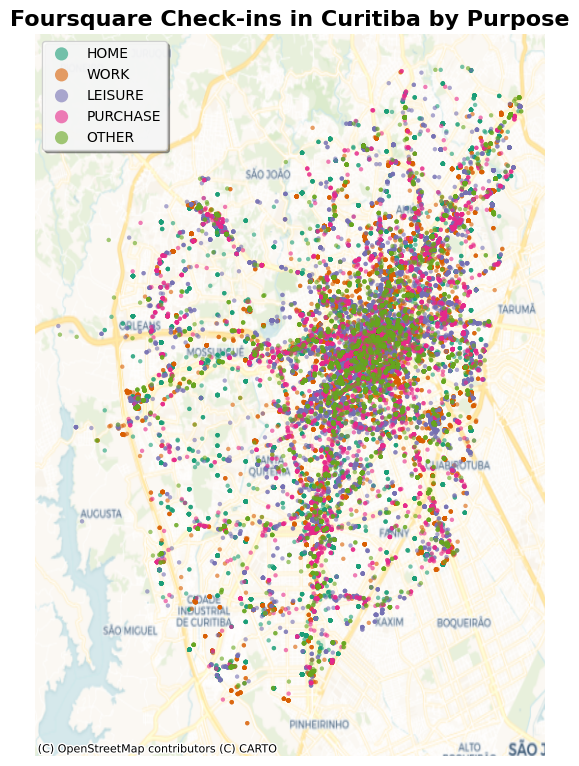

In [111]:
# Create a scatter plot with basemap
fig, ax = plt.subplots(figsize=(6, 8))

# Define colors for each purpose
purpose_colors = {
    'HOME': '#1b9e77',      # Red
    'WORK': '#d95f02',      # Teal  
    'LEISURE': '#7570b3',   # Blue
    'PURCHASE': '#e7298a',  # Green
    'OTHER': '#66a61e'      # Yellow
}

# Plot points for each purpose
for purpose, color in purpose_colors.items():
    purpose_data = df[df['PURPOSE'] == purpose]
    ax.scatter(purpose_data['LONG'], purpose_data['LAT'], 
              c=color, alpha=0.6, s=10, label=purpose, edgecolors='none')
# Add basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Voyager)

# Customize plot
ax.set_title('Foursquare Check-ins in Curitiba by Purpose', fontsize=16, fontweight='bold')

# Add legend
legend = ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, markerscale=3)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.axis('off')  # Turn off the axis
plt.show()

# Treinando e Avaliando Modelo

In [2]:
df = pd.read_csv('../dados/curitiba_foursquare_purpose.csv')
df

,ID_USER,DATE,CATEGORIA_MAE,Bairro,LAT,LONG,HOUR,DAY_OF_WEEK,DAY_NAME,PURPOSE
0,59907035,2014-02-12 13:54:32-02:00,Sandwiches,GUAÍRA,-25.469176,-49.282521,13,2,Wednesday,LEISURE
1,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
2,21015914,2014-03-24 16:46:41-03:00,Residential,PORTÃO,-25.474154,-49.290013,16,0,Monday,HOME
3,43112636,2014-04-23 23:45:41-03:00,Soccer,ÁGUA VERDE,-25.462514,-49.277967,23,2,Wednesday,LEISURE
4,37412621,2014-04-23 23:47:00-03:00,Home,CENTRO,-25.438156,-49.279074,23,2,Wednesday,HOME
...,...,...,...,...,...,...,...,...,...,...
53208,16620308,2014-06-18 18:38:07-03:00,Fried-Chicken,SÃO LOURENÇO,-25.397451,-49.271144,18,2,Wednesday,LEISURE
53209,12974483,2014-06-18 18:41:13-03:00,Shrine,ALTO DA GLÓRIA,-25.420876,-49.261371,18,2,Wednesday,OTHER
53210,17082636,2014-06-18 18:42:24-03:00,Mall,CENTRO,-25.440988,-49.277436,18,2,Wednesday,PURCHASE
53211,17082636,2014-06-18 18:42:35-03:00,Beer-Store,CENTRO,-25.440845,-49.277071,18,2,Wednesday,PURCHASE


In [ ]:
X = df[["Bairro", "HOUR", "DAY_OF_WEEK"]]
y = df["PURPOSE"]
groups = df["ID_USER"]

# Encode categorical variables
le_bairro = LabelEncoder()
le_purpose = LabelEncoder()

X_encoded = X.copy()
X_encoded['Bairro'] = le_bairro.fit_transform(X['Bairro'])
y_encoded = le_purpose.fit_transform(y)

# Initialize GroupKFold and results storage
group_kfold = GroupKFold(n_splits=5, shuffle=True, random_state=42)
results = []

all_y_true = []
all_y_pred = []

# Train and evaluate model for each fold
for fold, (train_index, test_index) in enumerate(group_kfold.split(X_encoded, y_encoded, groups)):
    print(f"Training Fold {fold + 1}...")
    
    # Split data
    X_train, X_test = X_encoded.iloc[train_index], X_encoded.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    # Create and train LightGBM model
    model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=len(le_purpose.classes_),
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        verbose=-1
    )
    
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    # Store predictions for aggregated confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    results.append({
        'Fold': fold + 1,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"Fold {fold + 1} completed.")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

Training Fold 1...
Fold 1 completed.
Training Fold 2...
Fold 2 completed.
Training Fold 3...
Fold 3 completed.
Training Fold 4...
Fold 4 completed.
Training Fold 5...
Fold 5 completed.


,Fold,Accuracy,Precision,Recall,F1-Score
0,1,0.508489,0.486904,0.508489,0.482539
1,2,0.496978,0.486379,0.496978,0.470197
2,3,0.510940,0.498066,0.510940,0.484337
3,4,0.523495,0.504197,0.523495,0.497320
4,5,0.503647,0.490269,0.503647,0.475740


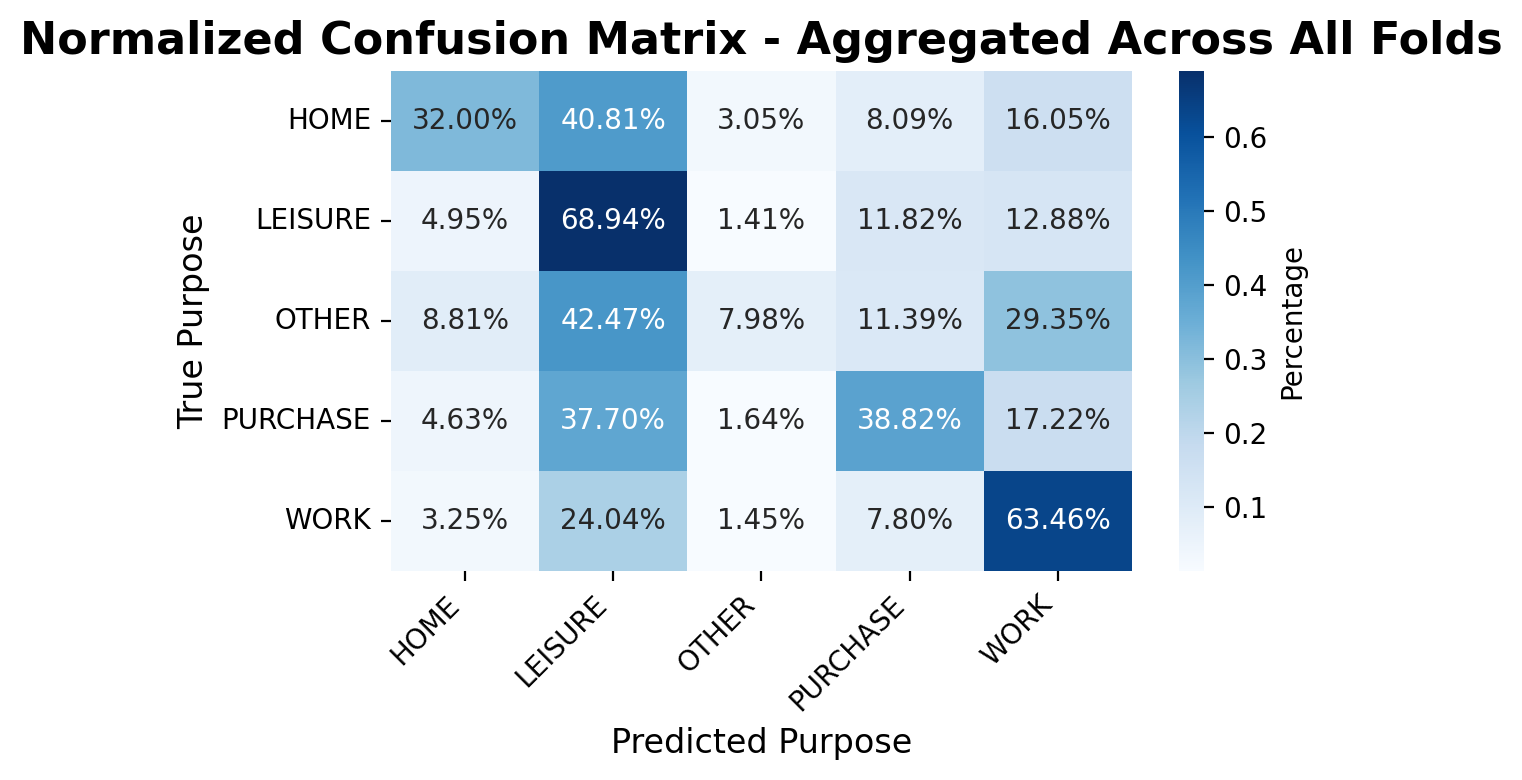

In [12]:
cm = confusion_matrix(all_y_true, all_y_pred)

# Convert back to original labels
class_names = le_purpose.classes_

# Calculate and display normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 4), dpi=200)
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt='.2%', 
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})

plt.title('Normalized Confusion Matrix - Aggregated Across All Folds', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Purpose', fontsize=12)
plt.ylabel('True Purpose', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Salvar o modelo

In [17]:
# Use the same encoders fitted earlier
X_final = X_encoded.copy()
y_final = y_encoded.copy()

# Create and train final LightGBM model
final_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(le_purpose.classes_),
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    verbose=-1
)

# Train on all data
final_model.fit(X_final, y_final)

# Save the trained model
model_path = "../modelos/lgb_purpose_model.pkl"
joblib.dump(final_model, model_path)
print(f"Model saved to: {model_path}")

# Save the encoders
encoders = {
    'le_bairro': le_bairro,
    'le_purpose': le_purpose,
    'feature_names': ['Bairro', 'HOUR', 'DAY_OF_WEEK'],
    'class_names': le_purpose.classes_.tolist()
}

encoders_path = "../modelos/lgb_purpose_encoders.pkl"
with open(encoders_path, 'wb') as f:
    pickle.dump(encoders, f)
print(f"Encoders saved to: {encoders_path}")

Model saved to: ../modelos/lgb_purpose_model.pkl
Encoders saved to: ../modelos/lgb_purpose_encoders.pkl


## Comparar com um random baseline

COMPARING WITH RANDOM BASELINE
Baseline Fold 1...
Baseline Fold 2...
Baseline Fold 3...
Baseline Fold 4...
Baseline Fold 5...

LIGHTGBM MODEL RESULTS:
----------------------------------------
   Fold  Accuracy  Precision  Recall  F1-Score
0     1    0.5085     0.4869  0.5085    0.4825
1     2    0.4970     0.4864  0.4970    0.4702
2     3    0.5109     0.4981  0.5109    0.4843
3     4    0.5235     0.5042  0.5235    0.4973
4     5    0.5036     0.4903  0.5036    0.4757

Mean LightGBM Performance:
Accuracy: 0.5087 ± 0.0098
Precision: 0.4932 ± 0.0077
Recall: 0.5087 ± 0.0098
F1-Score: 0.4820 ± 0.0102

RANDOM BASELINE RESULTS:
----------------------------------------
   Fold  Accuracy  Precision  Recall  F1-Score
0     1    0.2366     0.2352  0.2366    0.2358
1     2    0.2473     0.2447  0.2473    0.2457
2     3    0.2325     0.2324  0.2325    0.2323
3     4    0.2383     0.2428  0.2383    0.2403
4     5    0.2367     0.2329  0.2367    0.2343

Mean Baseline Performance:
Accuracy: 0.2383 ±

/tmp/ipykernel_22221/3422692187.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(data_to_plot, labels=['LightGBM', 'Random Baseline'], patch_artist=True)
/tmp/ipykernel_22221/3422692187.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(data_to_plot, labels=['LightGBM', 'Random Baseline'], patch_artist=True)
/tmp/ipykernel_22221/3422692187.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(data_to_plot, labels=['LightGBM', 'Random Baseline'], patch_artist=True)
/tmp/ipykernel_22221/3422692187.py:93: MatplotlibDeprecationWarning: The 'labels' par

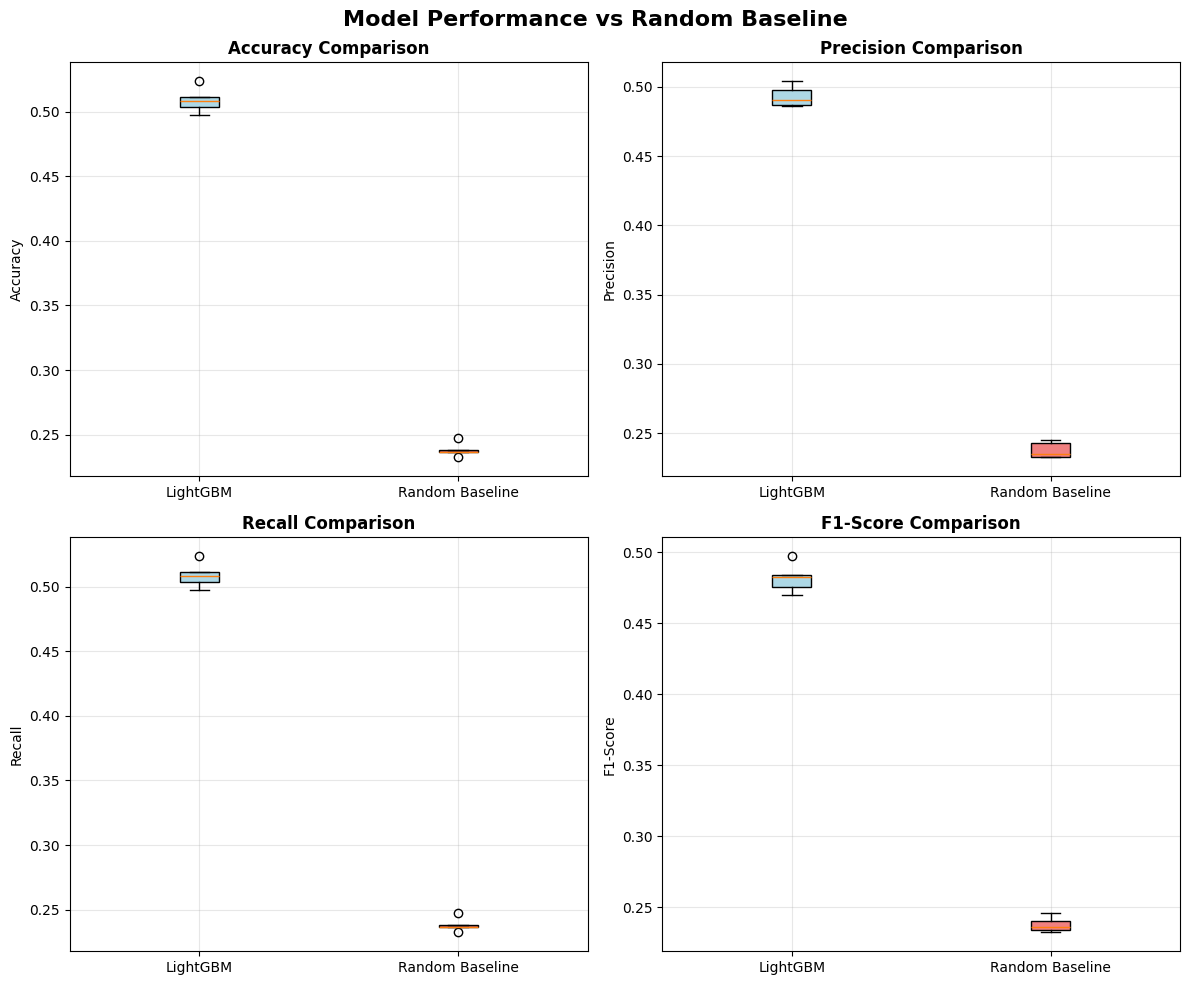


STATISTICAL SIGNIFICANCE TESTS (t-test):
--------------------------------------------------
Accuracy: t=44.904, p=0.000001 ***
Precision: t=61.231, p=0.000000 ***
Recall: t=44.904, p=0.000001 ***
F1-Score: t=43.557, p=0.000002 ***

Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant

CLASS DISTRIBUTION:
------------------------------
PURPOSE
HOME        0.1225
LEISURE     0.3441
OTHER       0.1129
PURCHASE    0.1788
WORK        0.2418
Name: proportion, dtype: float64

Most frequent class baseline accuracy: 0.3441


In [18]:
from sklearn.dummy import DummyClassifier
import numpy as np

print("="*60)
print("COMPARING WITH RANDOM BASELINE")
print("="*60)

# Initialize storage for baseline results
baseline_results = []
baseline_y_true = []
baseline_y_pred = []

# Run baseline evaluation with same cross-validation splits
for fold, (train_index, test_index) in enumerate(group_kfold.split(X_encoded, y_encoded, groups)):
    print(f"Baseline Fold {fold + 1}...")
    
    # Split data
    X_train, X_test = X_encoded.iloc[train_index], X_encoded.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    # Create random baseline (stratified random)
    baseline_model = DummyClassifier(strategy='stratified', random_state=42)
    baseline_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_baseline = baseline_model.predict(X_test)
    
    # Store predictions
    baseline_y_true.extend(y_test)
    baseline_y_pred.extend(y_pred_baseline)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_baseline)
    precision = precision_score(y_test, y_pred_baseline, average='weighted')
    recall = recall_score(y_test, y_pred_baseline, average='weighted')
    f1 = f1_score(y_test, y_pred_baseline, average='weighted')
    
    # Store results
    baseline_results.append({
        'Fold': fold + 1,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create baseline results DataFrame
baseline_df = pd.DataFrame(baseline_results)

# Compare results
print("\nLIGHTGBM MODEL RESULTS:")
print("-" * 40)
print(results_df.round(4))

print(f"\nMean LightGBM Performance:")
print(f"Accuracy: {results_df['Accuracy'].mean():.4f} ± {results_df['Accuracy'].std():.4f}")
print(f"Precision: {results_df['Precision'].mean():.4f} ± {results_df['Precision'].std():.4f}")
print(f"Recall: {results_df['Recall'].mean():.4f} ± {results_df['Recall'].std():.4f}")
print(f"F1-Score: {results_df['F1-Score'].mean():.4f} ± {results_df['F1-Score'].std():.4f}")

print("\nRANDOM BASELINE RESULTS:")
print("-" * 40)
print(baseline_df.round(4))

print(f"\nMean Baseline Performance:")
print(f"Accuracy: {baseline_df['Accuracy'].mean():.4f} ± {baseline_df['Accuracy'].std():.4f}")
print(f"Precision: {baseline_df['Precision'].mean():.4f} ± {baseline_df['Precision'].std():.4f}")
print(f"Recall: {baseline_df['Recall'].mean():.4f} ± {baseline_df['Recall'].std():.4f}")
print(f"F1-Score: {baseline_df['F1-Score'].mean():.4f} ± {baseline_df['F1-Score'].std():.4f}")

# Calculate improvement over baseline
print("\nIMPROVEMENT OVER BASELINE:")
print("-" * 40)
accuracy_improvement = (results_df['Accuracy'].mean() - baseline_df['Accuracy'].mean()) / baseline_df['Accuracy'].mean() * 100
precision_improvement = (results_df['Precision'].mean() - baseline_df['Precision'].mean()) / baseline_df['Precision'].mean() * 100
recall_improvement = (results_df['Recall'].mean() - baseline_df['Recall'].mean()) / baseline_df['Recall'].mean() * 100
f1_improvement = (results_df['F1-Score'].mean() - baseline_df['F1-Score'].mean()) / baseline_df['F1-Score'].mean() * 100

print(f"Accuracy improvement: {accuracy_improvement:.1f}%")
print(f"Precision improvement: {precision_improvement:.1f}%")
print(f"Recall improvement: {recall_improvement:.1f}%")
print(f"F1-Score improvement: {f1_improvement:.1f}%")

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    
    # Box plot comparison
    data_to_plot = [results_df[metric], baseline_df[metric]]
    box_plot = ax.boxplot(data_to_plot, labels=['LightGBM', 'Random Baseline'], patch_artist=True)
    
    # Color the boxes
    box_plot['boxes'][0].set_facecolor('lightblue')
    box_plot['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Performance vs Random Baseline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical significance test
from scipy import stats

print("\nSTATISTICAL SIGNIFICANCE TESTS (t-test):")
print("-" * 50)
for metric in metrics:
    statistic, p_value = stats.ttest_rel(results_df[metric], baseline_df[metric])
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{metric}: t={statistic:.3f}, p={p_value:.6f} {significance}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# Class distribution
print("\nCLASS DISTRIBUTION:")
print("-" * 30)
class_dist = pd.Series(y).value_counts(normalize=True).sort_index()
print(class_dist.round(4))

print(f"\nMost frequent class baseline accuracy: {class_dist.max():.4f}")